In [1]:
# =============================================================
#  A.E.D.A.S. — Validation du prétraitement
#  Notebook 02 : Vérification des features extraites
# =============================================================

import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from config import (
    FEATURES_PATH, METADATA_PATH, N_MFCC,
    MFCC_TIME_STEPS, SAMPLE_RATE, REPORTS_DIR
)

# Chargement
data = np.load(FEATURES_PATH)
features = data["features"]   # (8932, 13, 173)
labels   = data["labels"]     # (8932,)
mean     = data["mean"]       # (1, 13, 1)
std      = data["std"]        # (1, 13, 1)
meta     = pd.read_csv(METADATA_PATH)

print(f"Features shape  : {features.shape}")
print(f"Labels shape    : {labels.shape}")
print(f"Dtype features  : {features.dtype}")
print(f"Positifs        : {labels.sum()} ({labels.mean()*100:.1f}%)")
print(f"Négatifs        : {(labels==0).sum()}")
print(f"\nSources :\n{meta['source'].value_counts().to_string()}")
print(f"\nClasses :\n{meta['class'].value_counts().to_string()}")

Features shape  : (8932, 13, 173)
Labels shape    : (8932,)
Dtype features  : float32
Positifs        : 969 (10.8%)
Négatifs        : 7963

Sources :
source
urbansound8k    8732
esc50            200

Classes :
class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
engine_idling       1000
jackhammer          1000
drilling            1000
siren                969
car_horn             469
gun_shot             374
wind                  40
rain                  40
engine                40


In [2]:
# =============================================================
#  Cellule 2 : Vérification de la normalisation
# =============================================================

print("Vérification statistique de la normalisation Z-score")
print("=" * 50)

for i in range(N_MFCC):
    coef_mean = features[:, i, :].mean()
    coef_std  = features[:, i, :].std()
    print(f"  MFCC {i:02d} — mean : {coef_mean:+.6f}  |  std : {coef_std:.6f}")

print("\n✅ Tous les coefficients doivent être proches de mean≈0, std≈1")

# Vérification des valeurs aberrantes
global_min = features.min()
global_max = features.max()
print(f"\nMin global : {global_min:.3f}")
print(f"Max global : {global_max:.3f}")
print(f"Valeurs NaN : {np.isnan(features).sum()}")
print(f"Valeurs Inf : {np.isinf(features).sum()}")

if np.isnan(features).sum() == 0 and np.isinf(features).sum() == 0:
    print("\n✅ Aucune valeur aberrante détectée — dataset propre.")
else:
    print("\n⚠️  Valeurs aberrantes détectées — investigation nécessaire.")

Vérification statistique de la normalisation Z-score
  MFCC 00 — mean : +0.000000  |  std : 1.000001
  MFCC 01 — mean : +0.000000  |  std : 1.000000
  MFCC 02 — mean : +0.000000  |  std : 0.999999
  MFCC 03 — mean : -0.000000  |  std : 1.000000
  MFCC 04 — mean : +0.000000  |  std : 1.000001
  MFCC 05 — mean : +0.000000  |  std : 1.000000
  MFCC 06 — mean : -0.000000  |  std : 0.999999
  MFCC 07 — mean : +0.000000  |  std : 1.000001
  MFCC 08 — mean : -0.000000  |  std : 0.999999
  MFCC 09 — mean : -0.000000  |  std : 1.000001
  MFCC 10 — mean : -0.000000  |  std : 1.000000
  MFCC 11 — mean : -0.000000  |  std : 1.000000
  MFCC 12 — mean : -0.000000  |  std : 1.000001

✅ Tous les coefficients doivent être proches de mean≈0, std≈1

Min global : -9.454
Max global : 10.642
Valeurs NaN : 0
Valeurs Inf : 0

✅ Aucune valeur aberrante détectée — dataset propre.


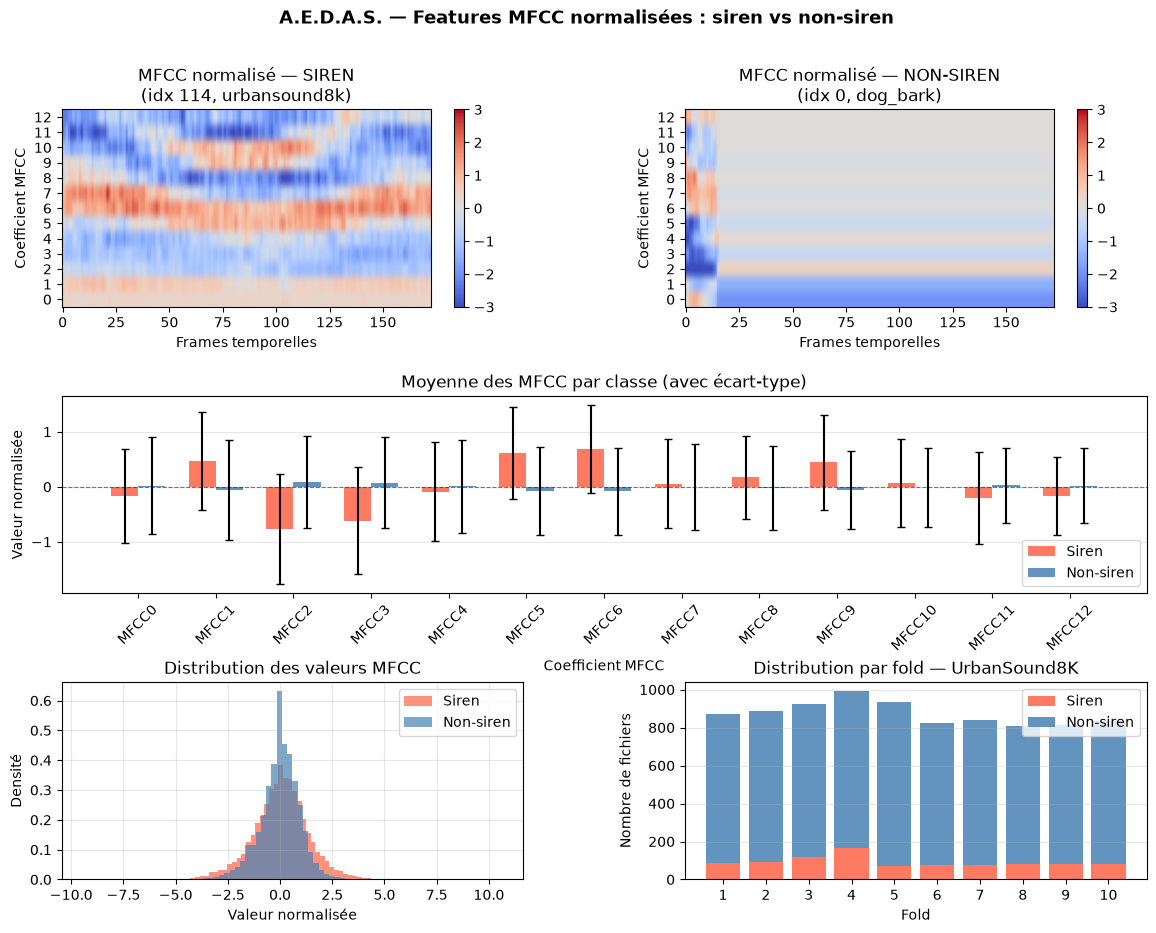

✅ Figure sauvegardée dans reports/


In [3]:
# =============================================================
#  Cellule 3 : Visualisation comparative siren vs non-siren
# =============================================================

fig = plt.figure(figsize=(14, 10))
fig.suptitle("A.E.D.A.S. — Features MFCC normalisées : siren vs non-siren",
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# Indices d'exemples représentatifs
idx_siren     = np.where(labels == 1)[0][0]
idx_nonsiren  = np.where(labels == 0)[0][0]

# ── Ligne 1 : MFCC matrices ──
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(features[idx_siren], aspect='auto', origin='lower',
                  cmap='coolwarm', vmin=-3, vmax=3)
ax1.set_title(f"MFCC normalisé — SIREN\n(idx {idx_siren}, {meta.iloc[idx_siren]['source']})")
ax1.set_xlabel("Frames temporelles")
ax1.set_ylabel("Coefficient MFCC")
ax1.set_yticks(range(N_MFCC))
plt.colorbar(im1, ax=ax1)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(features[idx_nonsiren], aspect='auto', origin='lower',
                  cmap='coolwarm', vmin=-3, vmax=3)
ax2.set_title(f"MFCC normalisé — NON-SIREN\n(idx {idx_nonsiren}, {meta.iloc[idx_nonsiren]['class']})")
ax2.set_xlabel("Frames temporelles")
ax2.set_ylabel("Coefficient MFCC")
ax2.set_yticks(range(N_MFCC))
plt.colorbar(im2, ax=ax2)

# ── Ligne 2 : Moyenne des MFCC par classe ──
ax3 = fig.add_subplot(gs[1, :])
mean_siren    = features[labels == 1].mean(axis=(0, 2))  # (13,)
mean_nonsiren = features[labels == 0].mean(axis=(0, 2))  # (13,)
std_siren     = features[labels == 1].mean(axis=2).std(axis=0)
std_nonsiren  = features[labels == 0].mean(axis=2).std(axis=0)

x = np.arange(N_MFCC)
width = 0.35
bars1 = ax3.bar(x - width/2, mean_siren,    width, label='Siren',
                color='tomato',    alpha=0.85, yerr=std_siren,    capsize=3)
bars2 = ax3.bar(x + width/2, mean_nonsiren, width, label='Non-siren',
                color='steelblue', alpha=0.85, yerr=std_nonsiren, capsize=3)
ax3.set_title("Moyenne des MFCC par classe (avec écart-type)")
ax3.set_xlabel("Coefficient MFCC")
ax3.set_ylabel("Valeur normalisée")
ax3.set_xticks(x)
ax3.set_xticklabels([f"MFCC{i}" for i in range(N_MFCC)], rotation=45)
ax3.legend()
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax3.grid(axis='y', alpha=0.3)

# ── Ligne 3 : Distribution des valeurs par classe ──
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(features[labels == 1].flatten(),  bins=80, color='tomato',
         alpha=0.7, label='Siren',     density=True)
ax4.hist(features[labels == 0].flatten(), bins=80, color='steelblue',
         alpha=0.7, label='Non-siren', density=True)
ax4.set_title("Distribution des valeurs MFCC")
ax4.set_xlabel("Valeur normalisée")
ax4.set_ylabel("Densité")
ax4.legend()
ax4.grid(alpha=0.3)

# ── Ligne 3 : Distribution par fold (déséquilibre) ──
ax5 = fig.add_subplot(gs[2, 1])
meta_us8k = meta[meta['source'] == 'urbansound8k']
folds      = sorted(meta_us8k['fold'].unique())
siren_per_fold    = [meta_us8k[(meta_us8k['fold']==f) & (meta_us8k['label']==1)].shape[0] for f in folds]
nonsiren_per_fold = [meta_us8k[(meta_us8k['fold']==f) & (meta_us8k['label']==0)].shape[0] for f in folds]
ax5.bar(folds, siren_per_fold,    label='Siren',     color='tomato',    alpha=0.85)
ax5.bar(folds, nonsiren_per_fold, label='Non-siren', color='steelblue', alpha=0.85,
        bottom=siren_per_fold)
ax5.set_title("Distribution par fold — UrbanSound8K")
ax5.set_xlabel("Fold")
ax5.set_ylabel("Nombre de fichiers")
ax5.set_xticks(folds)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

plt.savefig(f"{REPORTS_DIR}/validation_preprocessing.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée dans reports/")